### 1.Import thư viện PaddleOCR

In [ ]:
# Cài đặt uv và các thư viện Paddle bằng uv (Tối ưu tốc độ cài đặt)
!pip install -q uv

# Cài PaddlePaddle-GPU (dùng --find-links tới kho package chuẩn của Paddle)
!uv pip install paddlepaddle-gpu==3.2.0 --find-links https://www.paddlepaddle.org.cn/packages/stable/cu126/

# Cài PaddleOCR & PaddleX với các extras [ocr,ie,doc-parser]
!uv pip install "paddlex[ocr,ie]==3.7.2" "paddleocr[doc-parser]" pymupdf

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu130/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 571.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 MB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Kiểm tra cài thành công chưa?
import paddle
print("PaddlePaddle version:", paddle.__version__)
print("GPU available:", paddle.device.is_compiled_with_cuda())

import paddlex
print("paddlex version:", paddlex.__version__)

import paddleocr
print("PaddleOCR version:", paddleocr.__version__)

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle version: 3.3.0
GPU available: True
paddlex version: 3.7.2
PaddleOCR version: 3.7.0


In [ ]:
# Cài đặt safetensors tương thích từng hệ điều hành (Windows / Linux)
import sys
if sys.platform.startswith("win"):
    !uv pip install safetensors
else:
    !uv pip install https://paddle-whl.bj.bcebos.com/nightly/cu126/safetensors/safetensors-0.6.2.dev0-cp38-abi3-linux_x86_64.whl

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: packaging
    Found existing ins

In [ ]:
import os
os.kill(os.getpid(), 9)

### 2. Data

In [ ]:
# Code hiển thị ảnh
import matplotlib.pyplot as plt
from PIL import Image

def show_image(path_or_img, figsize=(5, 7), title=None):
    img = Image.open(path_or_img) if isinstance(path_or_img, str) else path_or_img
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

Downloading...
From: https://drive.google.com/uc?id=1895KZNAQLkyk5K6nPsitEsVlwBa42A25
To: /content/highlands_receipt.png
100%|██████████| 1.57M/1.57M [00:00<00:00, 173MB/s]


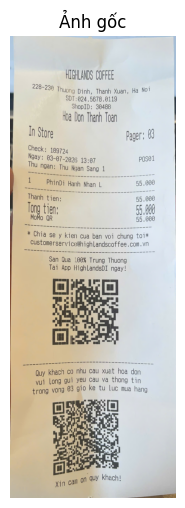

In [ ]:
!pip install -q gdown

import gdown
file_id = "1895KZNAQLkyk5K6nPsitEsVlwBa42A25"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "highlands_receipt.png", quiet=False)

show_image("highlands_receipt.png", figsize=(4, 6), title="Ảnh gốc")

### 3. PP-ChatOCRv4

In [ ]:
# chat_bot_config = {
#     "module_name": "chat_bot",
#     "model_name": "deepseek-chat",
#     "base_url": "https://api.deepseek.com/v1",
#     "api_type": "openai",
#     "api_key": "",
# }

# chat_bot_config = {
#     "module_name": "chat_bot",
#     "model_name": "grok-4.3",
#     "base_url": "https://api.x.ai/v1",
#     "api_type": "openai",
#     "api_key": "",
# }

chat_bot_config = {
    "module_name": "chat_bot",
    "model_name": "llama-3.3-70b-versatile",
    "base_url": "https://api.groq.com/openai/v1",
    "api_type": "openai",
    "api_key": "",
}

In [ ]:
from paddleocr import PPChatOCRv4Doc

pipeline = PPChatOCRv4Doc(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
)

visual_predict_res = pipeline.visual_predict(
    input="highlands_receipt.png",
    use_common_ocr=True,
    use_seal_recognition=False,
    use_table_recognition=False,
)

visual_info_list = []
for res in visual_predict_res:
    visual_info_list.append(res["visual_info"])
    layout_parsing_result = res["layout_parsing_result"]
    layout_parsing_result.save_to_img("output_chatocr")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('RT-DETR-H_layout_3cls', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/RT-DETR-H_layout_3cls`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv4_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_model

In [ ]:
print(visual_info_list)

[{'normal_text_dict': {'words in other_text': '228-230 Thuong Dinh，Thanh Xuan，Ha Noi\n SDT:024.5678.01.19\n ShopID:30488\n Hoa Don Thanh Toan\n In Store\n Check:189724\n Ngay:03-07-202613:07\n Thu ngan: Thu Ngan Sang 1\n PhinDi Hanh Nhan L\n Thanh tien:\n Tong tien:\n MoMo QR\n Pager:03\n POS01\n 55.000\n 55.000\n 55.000\n 55.000\n * Chia se y kien cua ban voi chung toi*\n customerservice@highlandscoffee.com.vn\n San Qua Loo% Trung Thuong\n Tai App HighlandsDI ngay!\n Quy khach co nhu cau xuat hoa don\n vui long gui yeu cau va thong tin\n trong vong 03 gio ke tu luc mua hang', 'words in image': '\n khach!'}, 'table_text_list': [], 'table_html_list': [], 'table_nei_text_list': []}]


In [ ]:
help(pipeline.chat)

Help on method chat in module paddleocr._pipelines.pp_chatocrv4_doc:

chat(key_list, visual_info, *, use_vector_retrieval=True, vector_info=None, min_characters=3500, text_task_description=None, text_output_format=None, text_rules_str=None, text_few_shot_demo_text_content=None, text_few_shot_demo_key_value_list=None, table_task_description=None, table_output_format=None, table_rules_str=None, table_few_shot_demo_text_content=None, table_few_shot_demo_key_value_list=None, mllm_predict_info=None, mllm_integration_strategy='integration', chat_bot_config=None, retriever_config=None) method of paddleocr._pipelines.pp_chatocrv4_doc.PPChatOCRv4Doc instance



In [ ]:
key_list = ["ten_cua_hang", "dia_chi", "ngay_gio", "tong_tien", "hinh_thuc_thanh_toan"]

chat_result = pipeline.chat(
    key_list=key_list,
    visual_info=visual_info_list,
    chat_bot_config=chat_bot_config
    )

print(chat_result["chat_res"])

{'dia_chi': '228-230 Thuong Dinh, Thanh Xuan, Ha Noi', 'ngay_gio': '03-07-2026 13:07', 'tong_tien': '55.000 VND', 'hinh_thuc_thanh_toan': 'MoMo QR'}


In [ ]:
import pandas as pd

result_dict = chat_result["chat_res"]
df_kie = pd.DataFrame(list(result_dict.items()), columns=["field", "giá trị trích xuất"])
df_kie

,field,giá trị trích xuất
0,dia_chi,"228-230 Thuong Dinh, Thanh Xuan, Ha Noi"
1,ngay_gio,03-07-2026 13:07
2,tong_tien,55.000 VND
3,hinh_thuc_thanh_toan,MoMo QR


In [ ]:
question_list = [
    "Khách hàng đã thanh toán bằng hình thức nào?",
    "Hoá đơn này có bao nhiêu món, tổng cộng bao nhiêu tiền?",
    "Cửa hàng nằm ở quận nào của Hà Nội?",
    "Nếu khách muốn xuất hoá đơn VAT thì cần làm gì theo thông tin trên hoá đơn?",
]

chat_result_qa = pipeline.chat(
    key_list=question_list,      # vẫn dùng tham số key_list, nhưng nội dung là câu hỏi
    visual_info=visual_info_list,
    chat_bot_config=chat_bot_config,
)

for q, a in chat_result_qa["chat_res"].items():
    print(f"Q: {q}\nA: {a}\n")

Q: Khách hàng đã thanh toán bằng hình thức nào?
A: MoMo QR Pager

Q: Cửa hàng nằm ở quận nào của Hà Nội?
A: Thanh Xuan

Q: Nếu khách muốn xuất hoá đơn VAT thì cần làm gì theo thông tin trên hoá đơn?
A: Quy khach co nhu cau xuat hoa don vui long gui yeu cau va thong tin trong vong 03 gio ke tu luc mua hang



### PaddleOCR-VL

In [ ]:
!pip install -U "paddleocr[doc-parser]"
!pip install https://paddle-whl.bj.bcebos.com/nightly/cu126/safetensors/safetensors-0.6.2.dev0-cp38-abi3-linux_x86_64.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.8/499.8 kB 103.3 kB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.8.0
    Uninstalling safetensors-0.8.0:
      Successfully uninstalled safetensors-0.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.38.0 requires safetensors>=0.8.0-rc.0, but you have safetensors 0.6.2.dev0 which is incompatible.
